In [67]:
using Revise
using SSMCMain, SSMCMain.ModifiedMiCRM, SSMCMain.ModifiedMiCRM.MinimalModelV2

In [68]:
using Base.Threads

In [110]:
using CairoMakie
using GLMakie
CairoMakie.activate!()

In [53]:
mmp = MMParams(;
    K=10.,
    m=1.,
    c=1.,
    l=1.,
)
ps = mmp_to_mmicrm(mmp; static=false);

In [137]:
ode_u0 = [1., 0., 0.]
tol = 1e5 * eps()
ode_p = make_mmicrm_problem(ps, ode_u0, 10;
    # usejac=false,
)
@time ode_s = solve(ode_p, QNDF();
    abstol=tol,
    reltol=tol,
);
@show mmicrmmaxresid(ode_s);

  0.000823 seconds (2.97 k allocations: 287.891 KiB)
mmicrmmaxresid(ode_s) = 0.0005598931359685951


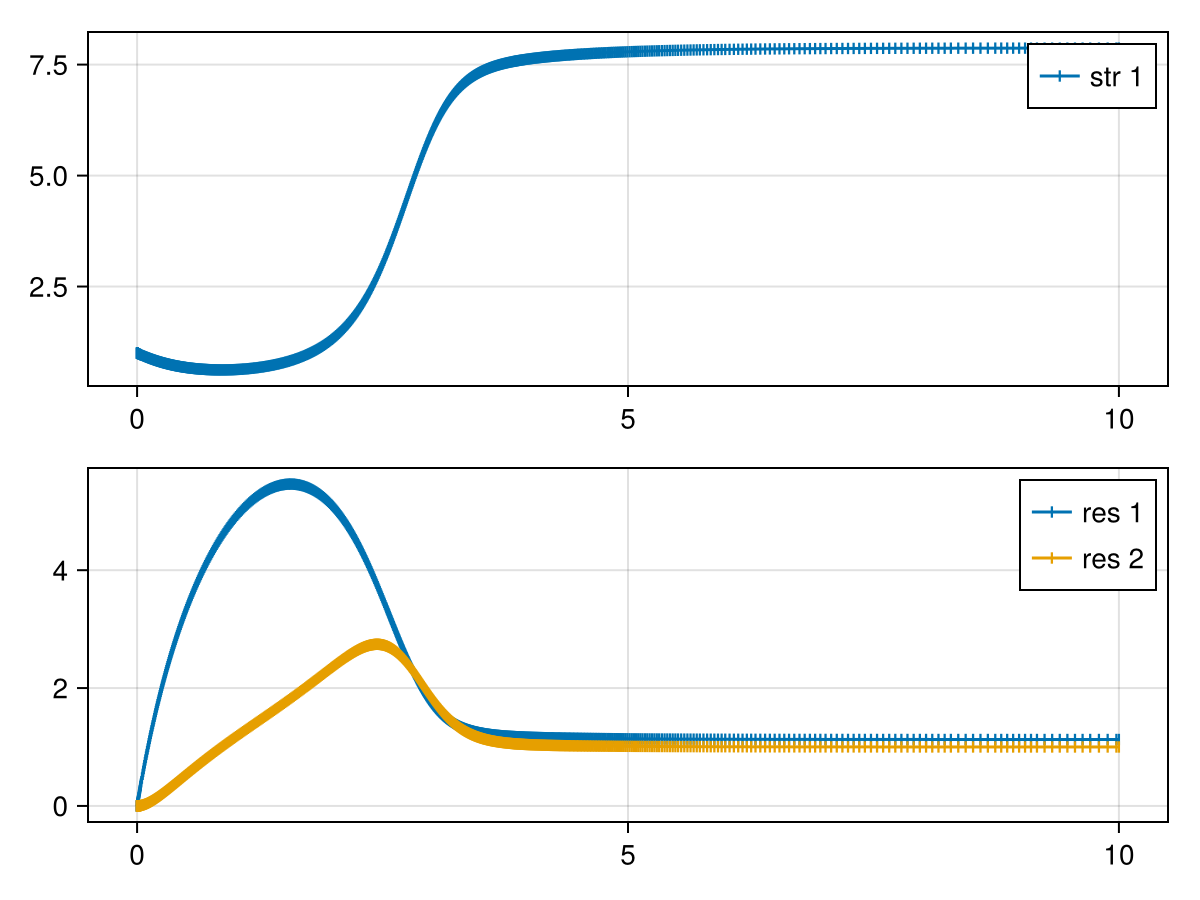

In [138]:
xx = plot_mmicrm_sol(ode_s)
xx.figure

In [ ]:
Ds = [1e-6, 1., 0.1]

sN = 2500
L = 5
dx = L / sN

pde_tol = 1e10 * eps()

u0 = expand_u0_to_size((sN,), ode_s.u[end])
u0 = perturb_u0_uniform(1, 2, u0, 1e-3)

sps = BSMMiCRMParams(ps, Ds,
    CartesianSpace{1,Tuple{Periodic}}(SA[dx]),
    nthreads(),
)

In [182]:
pde_p = make_smmicrm_problem(sps, u0, 1e8;
    jac_type=:both,
    # jac_type=:sparse,
    # jac_type=:true,
);

In [183]:
@time pde_s = solve(pde_p, QNDF();
    callback=make_timer_callback(10),
    abstol=pde_tol,
    reltol=pde_tol,
);
@show smmicrmmaxresid(pde_s)

  5.256607 seconds (2.26 M allocations: 2.365 GiB, 33.09% gc time)
smmicrmmaxresid(pde_s) = 4.874335601812163e-9


4.874335601812163e-9

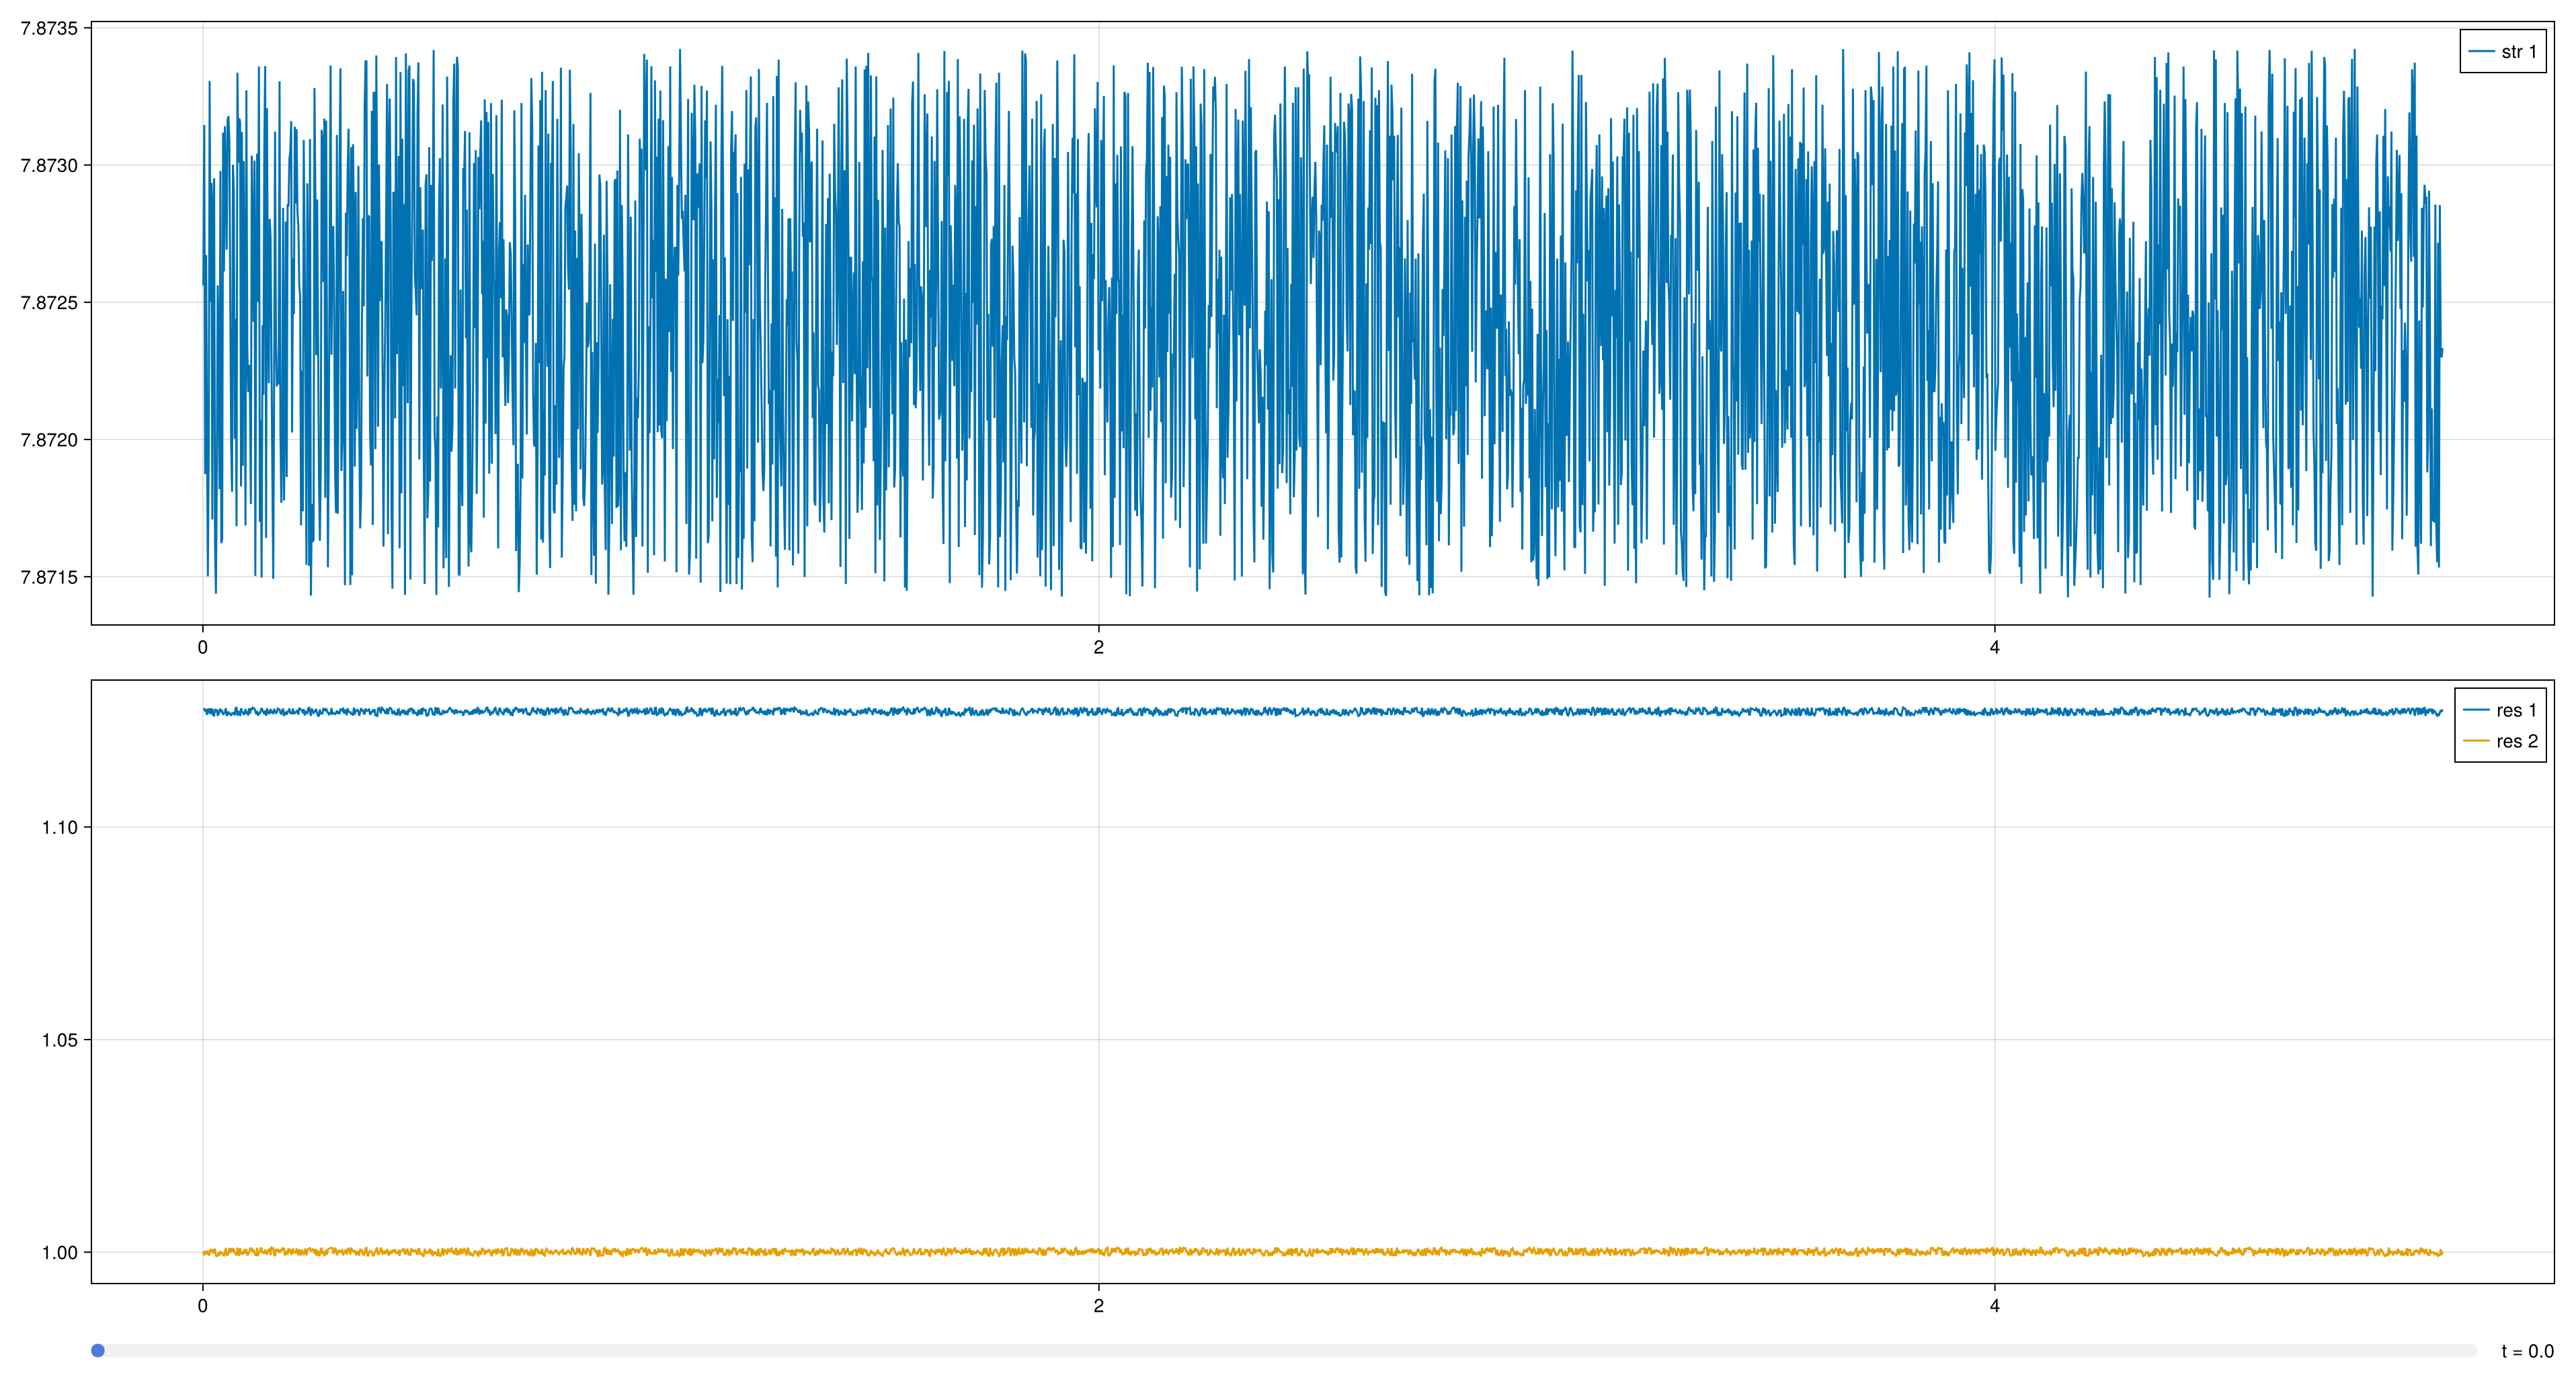

In [186]:
f = plot_1dsmmicrm_sol_interactive(xx)
display(GLMakie.Screen(), f)
f

In [179]:
pde_s.stats

SciMLBase.DEStats
Number of function 1 evaluations:                  9614
Number of function 2 evaluations:                  0
Number of W matrix evaluations:                    293
Number of linear solves:                           7110
Number of Jacobians created:                       98
Number of nonlinear solver iterations:             6365
Number of nonlinear solver convergence failures:   0
Number of fixed-point solver iterations:           0
Number of fixed-point solver convergence failures: 0
Number of rootfind condition calls:                1717
Number of accepted steps:                          1717
Number of rejected steps:                          96